In [1]:
import pandas as pd

pd.set_option("display.float_format", "{:.3f}".format)

df = pd.read_csv("en.openfoodfacts.org.products.csv", sep="\t", on_bad_lines="skip")

df.head()


C:\Users\De\AppData\Local\Temp\ipykernel_3768\3425291761.py:5: DtypeWarning: Columns (0,11,17,32,33,34,35,36,46,51,52,53,54,57,68,73) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("en.openfoodfacts.org.products.csv", sep="\t", on_bad_lines="skip")


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,...,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422.000,2025-02-22T06:23:42Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,63,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1673620307,2023-01-13T14:31:47Z,1750061386,2025-06-16T08:09:46Z,bodysupport,1750061386.000,2025-06-16T08:09:46Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,114,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1580066482,2020-01-26T19:21:22Z,1751035658,2025-06-27T14:47:38Z,teolemon,1751035658.000,2025-06-27T14:47:38Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,431,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1714301712,2024-04-28T10:55:12Z,1714301721,2024-04-28T10:55:21Z,kiliweb,1714301721.000,2024-04-28T10:55:21Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,105,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1572117743,2019-10-26T19:22:23Z,1738073570,2025-01-28T14:12:50Z,NaN,1743653496.000,2025-04-03T04:11:36Z,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



2. FEHLENDE WERTE (% der Zeilen)
origins_en                       96.168
manufacturing_places             95.126
packaging_en                     91.582
stores                           87.955
fruits-vegetables-legumes_100g   84.099
added-sugars_100g                83.274
fiber_100g                       77.558
nova_group                       74.917
labels_en                        72.775
main_category                    58.915
salt_100g                        57.295
sodium_100g                      57.295
saturated-fat_100g               53.360
sugars_100g                      53.025
fat_100g                         51.619
carbohydrates_100g               51.605
proteins_100g                    51.537
energy-kcal_100g                 51.099
energy_100g                      51.078
brands                           37.275
environmental_score_grade        19.225
product_name                      7.445
nutriscore_grade                  0.996
countries_en                      0.511
comple

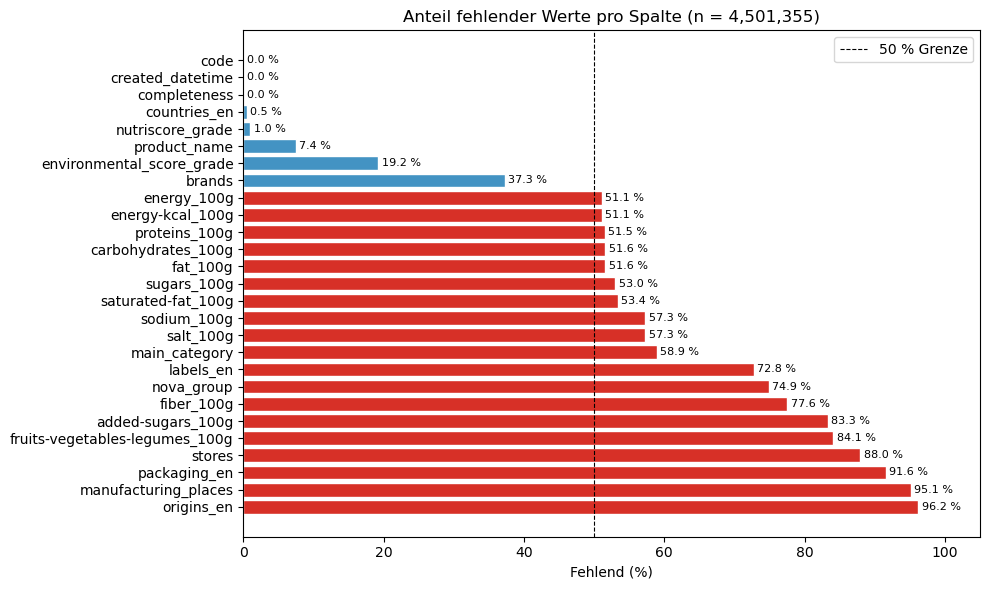

In [2]:
import matplotlib.pyplot as plt

test_col = ["code", "created_datetime", "product_name", "packaging_en", "brands", 
            "origins_en", "manufacturing_places", "labels_en", 
            "stores", "countries_en",
            "nutriscore_grade", "nova_group", "environmental_score_grade",
            "completeness", "main_category", "energy_100g", "energy-kcal_100g",
            "proteins_100g", "carbohydrates_100g", "fat_100g", "sugars_100g",
            "saturated-fat_100g", "salt_100g", "sodium_100g", "fiber_100g",
            "added-sugars_100g", "fruits-vegetables-legumes_100g"]

test_df = df[test_col].copy()
print("\n" + "=" * 55)
print("2. FEHLENDE WERTE (% der Zeilen)")
print("=" * 55)
missing = (test_df.isnull().sum() / len(test_df) * 100).sort_values(ascending=False)
print(missing.to_string())

# Visualisierung fehlender Werte
colors_mv = ["#d73027" if v > 50 else "#4393c3" for v in missing]
fig, ax = plt.subplots(figsize=(10, 6))
bars_mv = ax.barh(missing.index, missing.values, color=colors_mv, edgecolor="white")
for bar, val in zip(bars_mv, missing.values):
    ax.text(val + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{val:.1f} %", va="center", fontsize=8)
ax.set_xlabel("Fehlend (%)")
ax.set_title(f"Anteil fehlender Werte pro Spalte (n = {len(df):,})")
ax.axvline(50, color="black", linestyle="--", linewidth=0.8, label="50 % Grenze")
ax.set_xlim(0, 105)
ax.legend()
plt.tight_layout()
#plt.savefig("missing_values_neu.png", dpi=150)
plt.show()
#print("→ Grafik gespeichert: missing_values_neu.png")

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4501355 entries, 0 to 4501354
Data columns (total 210 columns):
 #    Column                            Non-Null Count    Dtype  
---   ------                            --------------    -----  
 0    code                              4501355 non-null  object 
 1    url                               4501355 non-null  object 
 2    creator                           4501349 non-null  object 
 3    created_t                         4501355 non-null  int64  
 4    created_datetime                  4501355 non-null  object 
 5    last_modified_t                   4501355 non-null  int64  
 6    last_modified_datetime            4501355 non-null  object 
 7    last_modified_by                  4362794 non-null  object 
 8    last_updated_t                    4501160 non-null  float64
 9    last_updated_datetime             4501160 non-null  object 
 10   product_name                      4166210 non-null  object 
 11   abbreviated_product_na

In [4]:
pd.set_option("display.max_columns", None)

df.head()


,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
0,54,http://world-en.openfoodfacts.org/product/0000...,kiliweb,1582569031,2020-02-24T18:30:31Z,1733085204,2024-12-01T20:33:24Z,NaN,1740205422.000,2025-02-22T06:23:42Z,Limonade artisanale a la rose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:fr,en:france,France,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-to-be-c...","en:to-be-completed,en:nutrition-facts-to-be-co...","To be completed,Nutrition facts to be complete...",NaN,NaN,unknown,NaN,NaN,NaN,NaN,NaN,NaN,0.163,1733085204.000,2024-12-01T20:33:24Z,NaN,Na

In [5]:
df.tail()

,code,url,creator,created_t,created_datetime,last_modified_t,last_modified_datetime,last_modified_by,last_updated_t,last_updated_datetime,product_name,abbreviated_product_name,generic_name,quantity,packaging,packaging_tags,packaging_en,packaging_text,brands,brands_tags,brands_en,categories,categories_tags,categories_en,origins,origins_tags,origins_en,manufacturing_places,manufacturing_places_tags,labels,labels_tags,labels_en,emb_codes,emb_codes_tags,first_packaging_code_geo,cities,cities_tags,purchase_places,stores,countries,countries_tags,countries_en,ingredients_text,ingredients_tags,ingredients_analysis_tags,allergens,allergens_en,traces,traces_tags,traces_en,serving_size,serving_quantity,no_nutrition_data,additives_n,additives,additives_tags,additives_en,nutriscore_score,nutriscore_grade,nova_group,pnns_groups_1,pnns_groups_2,food_groups,food_groups_tags,food_groups_en,states,states_tags,states_en,brand_owner,environmental_score_score,environmental_score_grade,nutrient_levels_tags,product_quantity,owner,data_quality_errors_tags,unique_scans_n,popularity_tags,completeness,last_image_t,last_image_datetime,main_category,main_category_en,image_url,image_small_url,image_ingredients_url,image_ingredients_small_url,image_nutrition_url,image_nutrition_small_url,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
4501350,9999999999901,http://world-en.openfoodfacts.org/product/9999...,gerardantoun,1771543016,2026-02-19T23:16:56Z,1771543299,2026-02-19T23:21:39Z,gerardantoun,1771543299.000,2026-02-19T23:21:39Z,Updated Test Bar,NaN,NaN,60g,NaN,NaN,NaN,NaN,NewBrand,xx:newbrand,newbrand,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,en:Switzerland,en:switzerland,Switzerland,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60g,60.000,NaN,NaN,NaN,NaN,NaN,NaN,unknown,NaN,unknown,unknown,NaN,NaN,NaN,"en:to-be-completed, en:nutrition-facts-complet...","en:to-be-completed,en:nutrition-facts-complete...","To be completed,Nutrition facts completed,Ingr...",NaN,NaN,unknown,NaN,60.000,NaN

In [6]:
df.describe()

,created_t,last_modified_t,last_updated_t,nova_group,environmental_score_score,product_quantity,unique_scans_n,completeness,last_image_t,energy-kj_100g,energy-kcal_100g,energy_100g,energy-from-fat_100g,fat_100g,saturated-fat_100g,butyric-acid_100g,caproic-acid_100g,caprylic-acid_100g,capric-acid_100g,lauric-acid_100g,myristic-acid_100g,palmitic-acid_100g,stearic-acid_100g,arachidic-acid_100g,behenic-acid_100g,lignoceric-acid_100g,cerotic-acid_100g,montanic-acid_100g,melissic-acid_100g,unsaturated-fat_100g,monounsaturated-fat_100g,omega-9-fat_100g,polyunsaturated-fat_100g,omega-3-fat_100g,omega-6-fat_100g,alpha-linolenic-acid_100g,eicosapentaenoic-acid_100g,docosahexaenoic-acid_100g,linoleic-acid_100g,arachidonic-acid_100g,gamma-linolenic-acid_100g,dihomo-gamma-linolenic-acid_100g,oleic-acid_100g,elaidic-acid_100g,gondoic-acid_100g,mead-acid_100g,erucic-acid_100g,nervonic-acid_100g,trans-fat_100g,cholesterol_100g,carbohydrates_100g,sugars_100g,added-sugars_100g,sucrose_100g,glucose_100g,fructose_100g,galactose_100g,lactose_100g,maltose_100g,maltodextrins_100g,psicose_100g,starch_100g,polyols_100g,erythritol_100g,isomalt_100g,maltitol_100g,sorbitol_100g,fiber_100g,soluble-fiber_100g,polydextrose_100g,insoluble-fiber_100g,proteins_100g,casein_100g,serum-proteins_100g,nucleotides_100g,salt_100g,added-salt_100g,sodium_100g,alcohol_100g,vitamin-a_100g,beta-carotene_100g,vitamin-d_100g,vitamin-e_100g,vitamin-k_100g,vitamin-c_100g,vitamin-b1_100g,vitamin-b2_100g,vitamin-pp_100g,vitamin-b6_100g,vitamin-b9_100g,folates_100g,vitamin-b12_100g,biotin_100g,pantothenic-acid_100g,silica_100g,bicarbonate_100g,potassium_100g,chloride_100g,calcium_100g,phosphorus_100g,iron_100g,magnesium_100g,zinc_100g,copper_100g,manganese_100g,fluoride_100g,selenium_100g,chromium_100g,molybdenum_100g,iodine_100g,caffeine_100g,taurine_100g,methylsulfonylmethane_100g,ph_100g,fruits-vegetables-legumes_100g,collagen-meat-protein-ratio_100g,cocoa_100g,chlorophyl_100g,carbon-footprint_100g,glycemic-index_100g,water-hardness_100g,choline_100g,phylloquinone_100g,beta-glucan_100g,inositol_100g,carnitine_100g,sulphate_100g,nitrate_100g,acidity_100g,carbohydrates-total_100g,water_100g
count,4501355.000,4501355.000,4501160.000,1129054.000,875975.000,1377385.000,1580372.000,4501302.000,3454588.000,2166196.000,2201194.000,2202164.000,458.000,2177811.000,2099429.000,29.000,12.000,15.000,17.000,29.000,25.000,49.000,24.000,224.000,91.000,18.000,10.000,23.000,22.000,162.000,26517.000,12.000,26249.000,633.000,290.000,1234.000,255.000,450.000,671.000,223.000,11.000,21.000,122.000,7.000,45.000,19.000,9.000,17.000,108067.000,341543.000,2178413.000,2114518.000,752876.000,234361.000,234640.000,234602.000,231115.000,235212.000,234141.000,212.000,20.000,265751.000,245406.000,118.000,1.000,12.000,11.000,1010215.000,973.000,5.000,804.000,2181475.000,91.000,111.000,44.000,1922304.000,72.000,1922304.000,271775.000,275301.000,230005.000,270031.000,272984.000,30869.000,289005.000,232717.000,232887.000,238211.000,244731.000,231490.000,1774.000,232285.000,1976.000,236579.000,268.000,1038.000,326810.000,15578.000,348422.000,271989.000,351933.000,275276.000,271900.000,267065.000,267384.000,1424.000,256033.000,398.000,450.000,232204.000,31956.000,311.000,1.000,603.000,715747.000,298.000,8237.000,10.000,412.000,9.000,15.000,37141.000,230042.000,65.000,188.000,163.000,621.000,402.000,36.000,1668.000,241489.000
mean,1645082945.485,1739404391.922,1759398303.904,3.342,51.503,227345604043137.906,3.280,0.417,1659648238.624,6215.618,6465898505.683,6145.868,476.277,22.260,5.483,310344829.869,7.714,17.971,14.406,29.382,11.240,4.089,7.426,1.070,0.811,3.172,0.801,5.365,5.503,11.380,15.960,8.229,676.746,29.823,6.799,7466868.028,33.522,26.932,3.506,2.618,2.255,22.641,19.062,1.329,0.114,0.531,0.002,1.546,0.412,29.417,33.345,555548552504372176365813760.000,132832.382,7.719,1.079,1.549,0.077,0.836,0.174,2.686,13.666,8.614,1.190,7.804,86.000,19.985,15.736,13.563,3.174,7.500,5.771,1704.729,1.854,11.578,10.137,116.3

In [7]:
pd.set_option("display.max_seq_items", None)
df.columns

Index(['code', 'url', 'creator', 'created_t', 'created_datetime',
       'last_modified_t', 'last_modified_datetime', 'last_modified_by',
       'last_updated_t', 'last_updated_datetime', 'product_name',
       'abbreviated_product_name', 'generic_name', 'quantity', 'packaging',
       'packaging_tags', 'packaging_en', 'packaging_text', 'brands',
       'brands_tags', 'brands_en', 'categories', 'categories_tags',
       'categories_en', 'origins', 'origins_tags', 'origins_en',
       'manufacturing_places', 'manufacturing_places_tags', 'labels',
       'labels_tags', 'labels_en', 'emb_codes', 'emb_codes_tags',
       'first_packaging_code_geo', 'cities', 'cities_tags', 'purchase_places',
       'stores', 'countries', 'countries_tags', 'countries_en',
       'ingredients_text', 'ingredients_tags', 'ingredients_analysis_tags',
       'allergens', 'allergens_en', 'traces', 'traces_tags', 'traces_en',
       'serving_size', 'serving_quantity', 'no_nutrition_data', 'additives_n',
       'ad

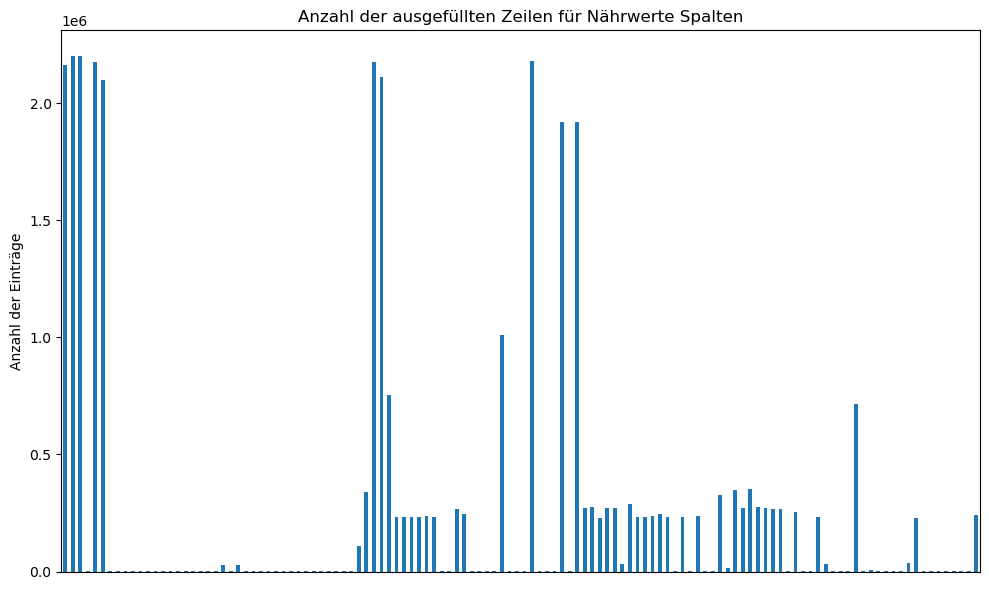

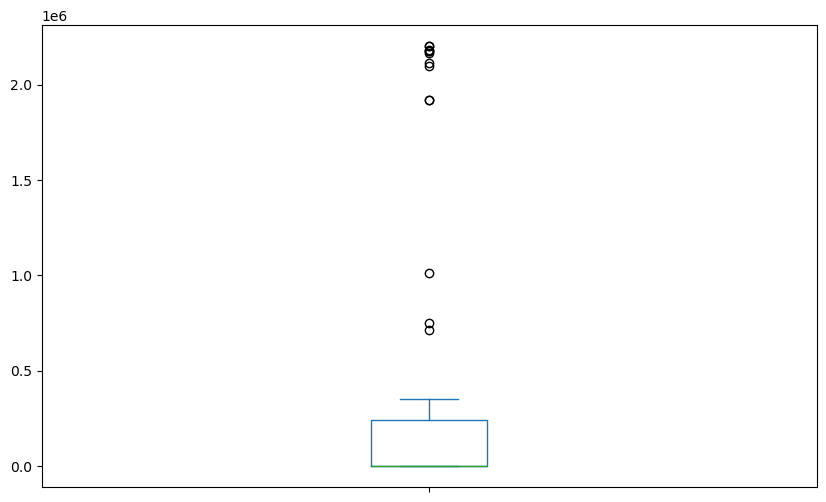

In [8]:
import matplotlib.pyplot as plt


nut_columns = ['energy-kj_100g', 'energy-kcal_100g',
       'energy_100g', 'energy-from-fat_100g', 'fat_100g', 'saturated-fat_100g',
       'butyric-acid_100g', 'caproic-acid_100g', 'caprylic-acid_100g',
       'capric-acid_100g', 'lauric-acid_100g', 'myristic-acid_100g',
       'palmitic-acid_100g', 'stearic-acid_100g', 'arachidic-acid_100g',
       'behenic-acid_100g', 'lignoceric-acid_100g', 'cerotic-acid_100g',
       'montanic-acid_100g', 'melissic-acid_100g', 'unsaturated-fat_100g',
       'monounsaturated-fat_100g', 'omega-9-fat_100g',
       'polyunsaturated-fat_100g', 'omega-3-fat_100g', 'omega-6-fat_100g',
       'alpha-linolenic-acid_100g', 'eicosapentaenoic-acid_100g',
       'docosahexaenoic-acid_100g', 'linoleic-acid_100g',
       'arachidonic-acid_100g', 'gamma-linolenic-acid_100g',
       'dihomo-gamma-linolenic-acid_100g', 'oleic-acid_100g',
       'elaidic-acid_100g', 'gondoic-acid_100g', 'mead-acid_100g',
       'erucic-acid_100g', 'nervonic-acid_100g', 'trans-fat_100g',
       'cholesterol_100g', 'carbohydrates_100g', 'sugars_100g',
       'added-sugars_100g', 'sucrose_100g', 'glucose_100g', 'fructose_100g',
       'galactose_100g', 'lactose_100g', 'maltose_100g', 'maltodextrins_100g',
       'psicose_100g', 'starch_100g', 'polyols_100g', 'erythritol_100g',
       'isomalt_100g', 'maltitol_100g', 'sorbitol_100g', 'fiber_100g',
       'soluble-fiber_100g', 'polydextrose_100g', 'insoluble-fiber_100g',
       'proteins_100g', 'casein_100g', 'serum-proteins_100g',
       'nucleotides_100g', 'salt_100g', 'added-salt_100g', 'sodium_100g',
       'alcohol_100g', 'vitamin-a_100g', 'beta-carotene_100g',
       'vitamin-d_100g', 'vitamin-e_100g', 'vitamin-k_100g', 'vitamin-c_100g',
       'vitamin-b1_100g', 'vitamin-b2_100g', 'vitamin-pp_100g',
       'vitamin-b6_100g', 'vitamin-b9_100g', 'folates_100g',
       'vitamin-b12_100g', 'biotin_100g', 'pantothenic-acid_100g',
       'silica_100g', 'bicarbonate_100g', 'potassium_100g', 'chloride_100g',
       'calcium_100g', 'phosphorus_100g', 'iron_100g', 'magnesium_100g',
       'zinc_100g', 'copper_100g', 'manganese_100g', 'fluoride_100g',
       'selenium_100g', 'chromium_100g', 'molybdenum_100g', 'iodine_100g',
       'caffeine_100g', 'taurine_100g', 'methylsulfonylmethane_100g',
       'ph_100g', 'fruits-vegetables-legumes_100g',
       'collagen-meat-protein-ratio_100g', 'cocoa_100g', 'chlorophyl_100g',
       'carbon-footprint_100g', 'glycemic-index_100g', 'water-hardness_100g',
       'choline_100g', 'phylloquinone_100g', 'beta-glucan_100g',
       'inositol_100g', 'carnitine_100g', 'sulphate_100g', 'nitrate_100g',
       'acidity_100g', 'carbohydrates-total_100g', 'water_100g']


df[nut_columns].count().plot(kind="bar", figsize=(10,6))

plt.title("Anzahl der ausgefüllten Zeilen für Nährwerte Spalten")
plt.ylabel("Anzahl der Einträge")

plt.xticks([])

plt.tight_layout()
#plt.savefig('mein_erstes_diagramm.png', dpi=300, bbox_inches='tight')
plt.show()


df[nut_columns].count().plot(kind="box", figsize=(10,6))
#plt.savefig('mein_erstes_diagramm.png', dpi=300, bbox_inches='tight')
plt.show()

In [9]:
# 1. Zähle die Einträge pro Spalte (wie beim Boxplot)
eintraege = df[nut_columns].count()

# 2. Berechne das 25%-Quartil (Q1) und das 75%-Quartil (Q3)
Q1 = eintraege.quantile(0.25)
Q3 = eintraege.quantile(0.75)

# 3. Berechne den Interquartilsabstand (IQR)
IQR = Q3 - Q1

# 4. Definiere die exakten Grenzen des Boxplots
untere_grenze = Q1 - 1.5 * IQR
obere_grenze = Q3 + 1.5 * IQR

print(f"Normale Spalten haben zwischen {untere_grenze:.0f} und {obere_grenze:.0f} Einträgen.\n")

# 5. Filtere die Spalten heraus, die außerhalb liegen
ausreisser_spalten = eintraege[(eintraege < untere_grenze) | (eintraege > obere_grenze)]

# 6. Sortiere sie absteigend und zeige sie an
ausreisser_spalten = ausreisser_spalten.sort_values(ascending=False)

print("Das sind die Ausreißer-Spalten und ihre Anzahl an Einträgen:")
print(ausreisser_spalten)

# Wenn du nur die Namen als Liste brauchst, um damit weiterzuarbeiten:
ausreisser_namen_liste = ausreisser_spalten.index.tolist()


Normale Spalten haben zwischen -365748 und 609722 Einträgen.

Das sind die Ausreißer-Spalten und ihre Anzahl an Einträgen:
energy_100g                       2202164
energy-kcal_100g                  2201194
proteins_100g                     2181475
carbohydrates_100g                2178413
fat_100g                          2177811
energy-kj_100g                    2166196
sugars_100g                       2114518
saturated-fat_100g                2099429
salt_100g                         1922304
sodium_100g                       1922304
fiber_100g                        1010215
added-sugars_100g                  752876
fruits-vegetables-legumes_100g     715747
dtype: int64


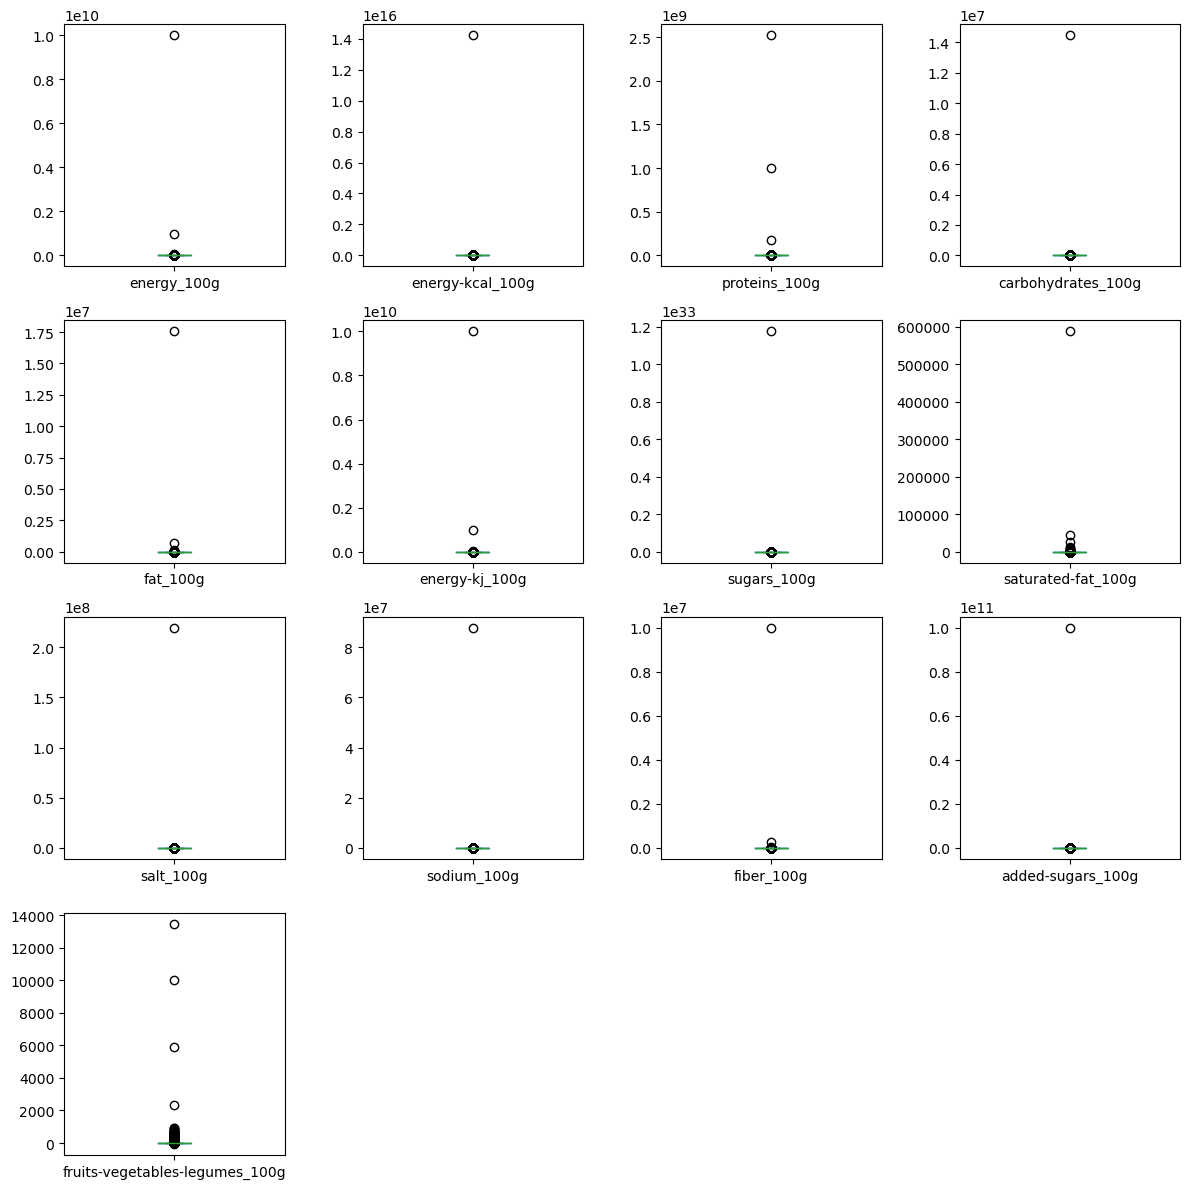

In [10]:
df[ausreisser_namen_liste].plot(kind="box", subplots=True, layout=(4,4), figsize=(12,12), sharey=False)

plt.tight_layout()
#plt.savefig('boxplots_nährwerte.png', dpi=300, bbox_inches='tight')
plt.show()


In [11]:
df[ausreisser_namen_liste].describe()

,energy_100g,energy-kcal_100g,proteins_100g,carbohydrates_100g,fat_100g,energy-kj_100g,sugars_100g,saturated-fat_100g,salt_100g,sodium_100g,fiber_100g,added-sugars_100g,fruits-vegetables-legumes_100g
count,2202164.000,2201194.000,2181475.000,2178413.000,2177811.000,2166196.000,2114518.000,2099429.000,1922304.000,1922304.000,1010215.000,752876.000,715747.000
mean,6145.868,6465898505.683,1704.729,33.345,22.260,6215.618,555548552504372176365813760.000,5.483,116.370,46.566,13.563,132832.382,14.335
std,6770143.420,9593078995948.131,1840637.389,9810.668,11904.178,6826059.307,807844390361581177423785885696.000,407.591,158330.703,63332.284,9952.696,115249293.950,35.968
min,-2333.333,-113.860,-4.762,-0.115,-0.002,-2333.333,-0.087,-3.992,-0.454,-0.183,-3.333,-22.520,-65.887
25%,461.600,109.000,2.000,3.000,1.170,469.400,0.600,0.200,0.098,0.039,0.157,0.000,0.000
50%,1061.000,253.333,6.700,14.000,7.300,1070.200,3.200,1.900,0.570,0.228,1.667,0.000,0.000
75%,1654.000,394.000,14.000,50.000,21.000,1656.400,14.400,7.000,1.400,0.560,3.900,6.177,10.680
max,10000000000.000,14232696253056154.000,2522222222.000,14479774.250,17554003.530,10000000000.000,1174717414144440050270536724381696.000,588000.000,219520780.944,87808312.377,10000000.000,100000000000.000,13461.000


In [12]:
spalten_info = pd.DataFrame({"Anzahl Einträge": df.count(), "Einzigartige Werte": df.nunique(), "Datentyp": df.dtypes})
spalten_info["Anzahl Duplikate"] = spalten_info["Anzahl Einträge"] - spalten_info["Einzigartige Werte"]
pd.set_option("display.width", 1000)
pd.set_option("display.max_rows", None)

print(spalten_info)

                                  Anzahl Einträge  Einzigartige Werte Datentyp  Anzahl Duplikate
code                                      4501355             4501289   object                66
url                                       4501355             4501317   object                38
creator                                   4501349               42869   object           4458480
created_t                                 4501355             4165472    int64            335883
created_datetime                          4501355             4165472   object            335883
last_modified_t                           4501355             2707568    int64           1793787
last_modified_datetime                    4501355             2707568   object           1793787
last_modified_by                          4362794               32427   object           4330367
last_updated_t                            4501160             1957086  float64           2544074
last_updated_datetime         

In [13]:
temp = ["pnns_groups_1"]
pd.reset_option("display.width")
print(df[temp].dropna().sample(10))

                   pnns_groups_1
4271954                  unknown
2033847  Milk and dairy products
3547240                  unknown
4025113                  unknown
2399116    Fruits and vegetables
837297                   unknown
1041535                  unknown
3446510            Sugary snacks
3017468            Sugary snacks
3635027                  unknown


In [14]:
moegliche_felder = df.size
ausgefuellte_felder = df.count().sum()

ausfuellgrad = (ausgefuellte_felder / moegliche_felder) * 100

print(ausfuellgrad)

21.37445883358614


In [15]:
filtered_col = ["code", "product_name", "quantity", "packaging_en", "brands", 
                "categories_en", "origins_en", "manufacturing_places", "labels_en", "first_packaging_code_geo", 
                "purchase_places", "stores", "countries_en", "ingredients_tags", "ingredients_analysis_tags",
                "allergens", "traces_en", "serving_quantity", "additives_n", "additives_en",
                "nutriscore_grade", "nova_group", "pnns_groups_1", "pnns_groups_2", "food_groups_en",
                "states_en", "brand_owner", "environmental_score_grade", "nutrient_levels_tags", "product_quantity", 
                "data_quality_errors_tags", "unique_scans_n", "completeness","main_category"]

fdf = df[filtered_col].copy()

fdf.shape

(4501355, 34)

In [16]:
filtered_spalten_info = pd.DataFrame({"Anzahl Einträge": fdf.count(), "Einzigartige Werte": fdf.nunique(), "Datentyp": fdf.dtypes})
filtered_spalten_info["Anzahl Duplikate"] = filtered_spalten_info["Anzahl Einträge"] - filtered_spalten_info["Einzigartige Werte"]
pd.set_option("display.width", 1000)
pd.set_option("display.max_rows", None)

print(filtered_spalten_info)

                           Anzahl Einträge  Einzigartige Werte Datentyp  Anzahl Duplikate
code                               4501355             4501289   object                66
product_name                       4166210             2614937   object           1551273
quantity                           1431578               74000   object           1357578
packaging_en                        378933               48893   object            330040
brands                             2823491              478131   object           2345360
categories_en                      1849385              195961   object           1653424
origins_en                          172496               19274   object            153222
manufacturing_places                219409               38130   object            181279
labels_en                          1225498              132579   object           1092919
first_packaging_code_geo             94467                4425   object             90042
purchase_p

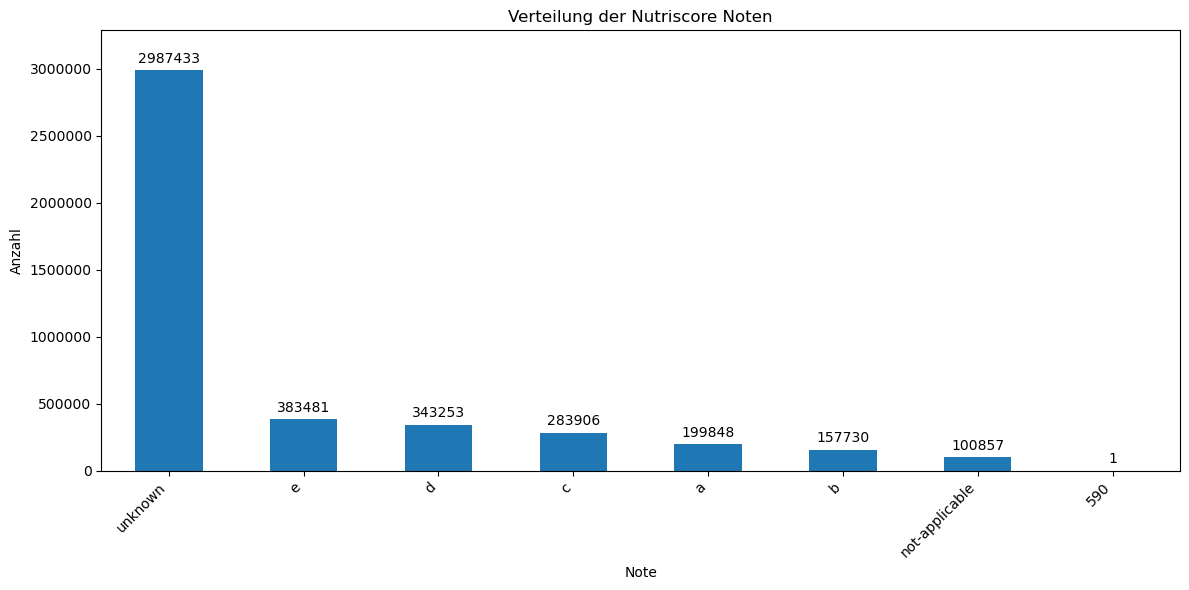

In [17]:
v1 = fdf["nutriscore_grade"].value_counts().plot(kind="bar", figsize=(12, 6), title="Verteilung der Nutriscore Noten")
v1.set_xlabel("Note")
v1.set_ylabel("Anzahl")
v1.ticklabel_format(style="plain", axis="y")
v1.bar_label(v1.containers[0], padding=3, fmt="%d")

plt.margins(y=0.1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig('nutriscore.png', dpi=300, bbox_inches='tight')
plt.show()


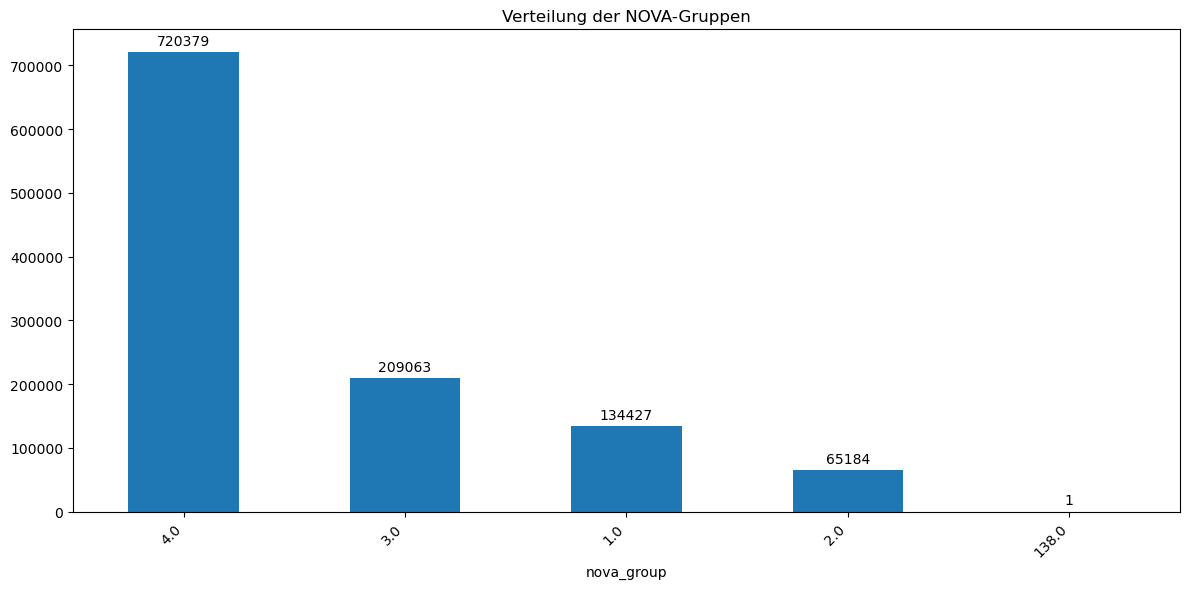

In [18]:
v2 = fdf["nova_group"].value_counts().plot(kind="bar", figsize=(12,6), x="Gruppen", y="Anzahl", title="Verteilung der NOVA-Gruppen")
v2.bar_label(v2.containers[0], padding=3, fmt="%d")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig('nova_gruppen.png', dpi=300, bbox_inches='tight')
plt.show()

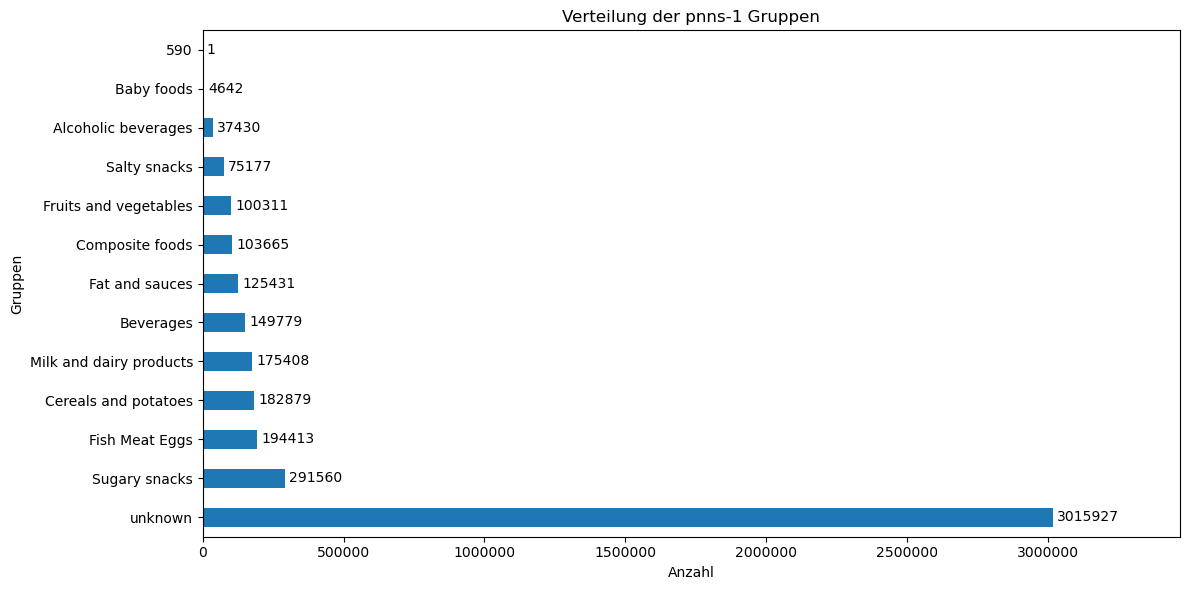

In [19]:
v3 = fdf["pnns_groups_1"].value_counts().plot(kind="barh", figsize=(12,6), title="Verteilung der pnns-1 Gruppen")
v3.set_xlabel("Anzahl")
v3.set_ylabel("Gruppen")
v3.ticklabel_format(style="plain", axis="x")
v3.bar_label(v3.containers[0], padding=3, fmt="%d")

plt.margins(x=0.15)
plt.tight_layout()
plt.show()

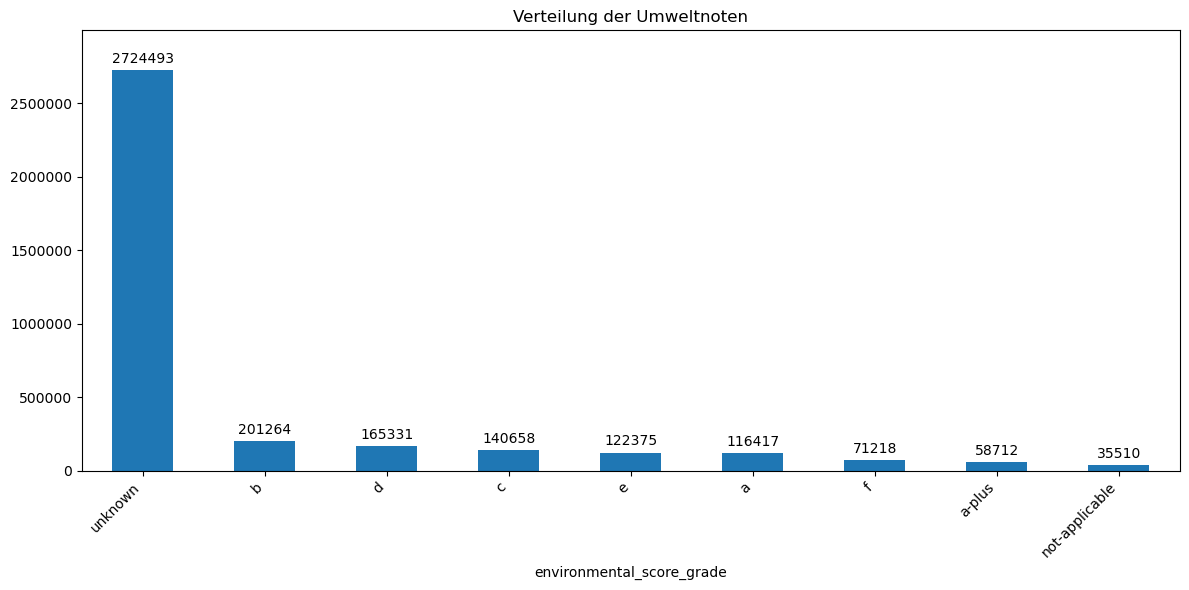

In [20]:
v4 = fdf["environmental_score_grade"].value_counts().plot(kind="bar", figsize=(12,6),  x="Noten", y="Anzahl", title="Verteilung der Umweltnoten")
v4.ticklabel_format(style="plain", axis="y")
v4.bar_label(v4.containers[0], padding=3, fmt="%d")

plt.margins(y=0.1)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
#plt.savefig('umweltnoten.png', dpi=300, bbox_inches='tight')
plt.show()

In [21]:
fdf["quantity"].value_counts().head(10)

quantity
1pcs            59983
500 g           43961
200 g           38192
250 g           38073
100 g           30302
400 g           26978
150 g           24064
300 g           23593
1 serving(s)    22268
500g            21852
Name: count, dtype: int64

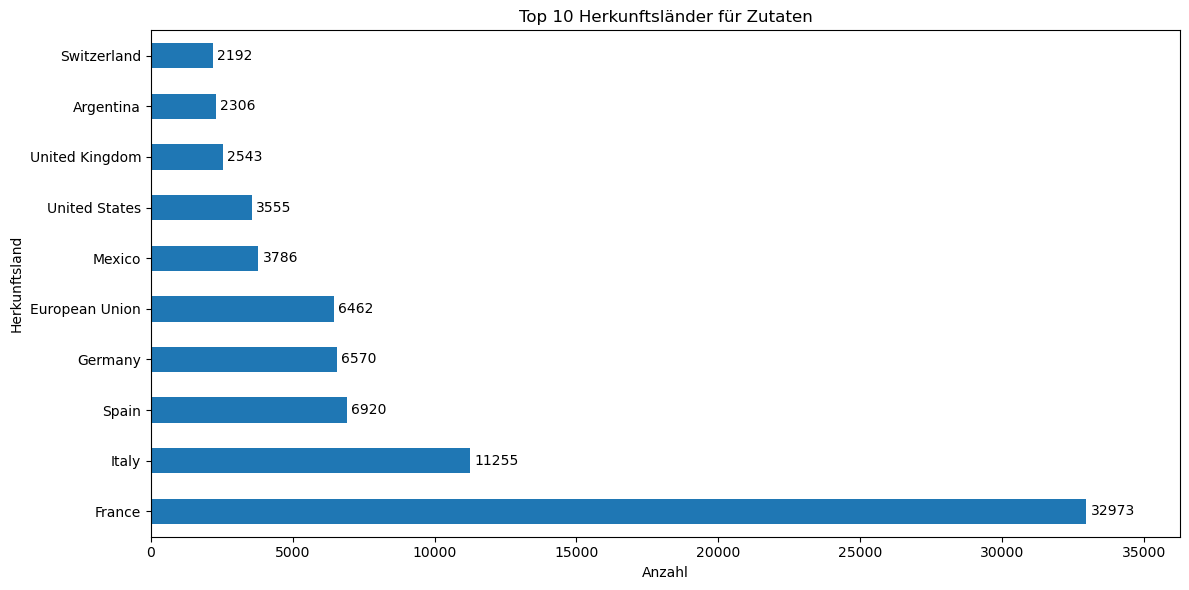

In [22]:
v5 = fdf["origins_en"].value_counts().head(10).plot(kind="barh", figsize=(12,6), title="Top 10 Herkunftsländer für Zutaten")
v5.set_xlabel("Anzahl")
v5.set_ylabel("Herkunftsland")
v5.ticklabel_format(style="plain", axis="x")
v5.bar_label(v5.containers[0], padding=3, fmt="%d")

plt.margins(x=0.1)
plt.tight_layout()
#plt.savefig('top10_herkunftsländer.png', dpi=300, bbox_inches='tight')
plt.show()

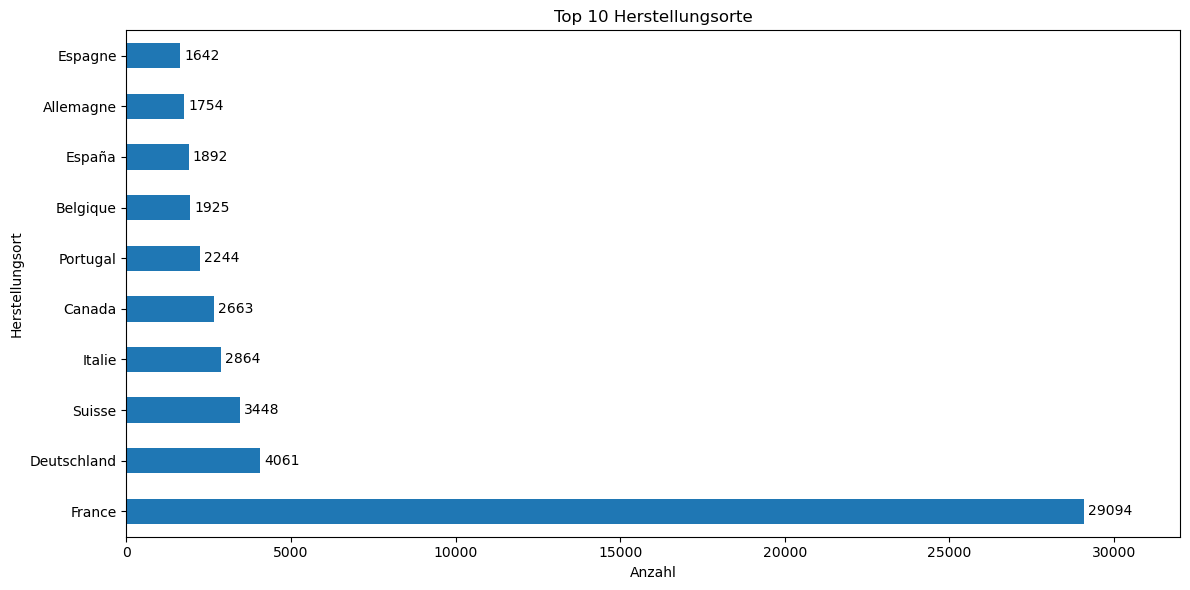

In [23]:
v6 = fdf["manufacturing_places"].value_counts().head(10).plot(kind="barh", figsize=(12,6), title="Top 10 Herstellungsorte")
v6.set_xlabel("Anzahl")
v6.set_ylabel("Herstellungsort")
v6.ticklabel_format(style="plain", axis="x")
v6.bar_label(v6.containers[0], padding=3, fmt="%d")

plt.margins(x=0.1)
plt.tight_layout()
#plt.savefig('top10_herstellungsorte.png', dpi=300, bbox_inches='tight')
plt.show()

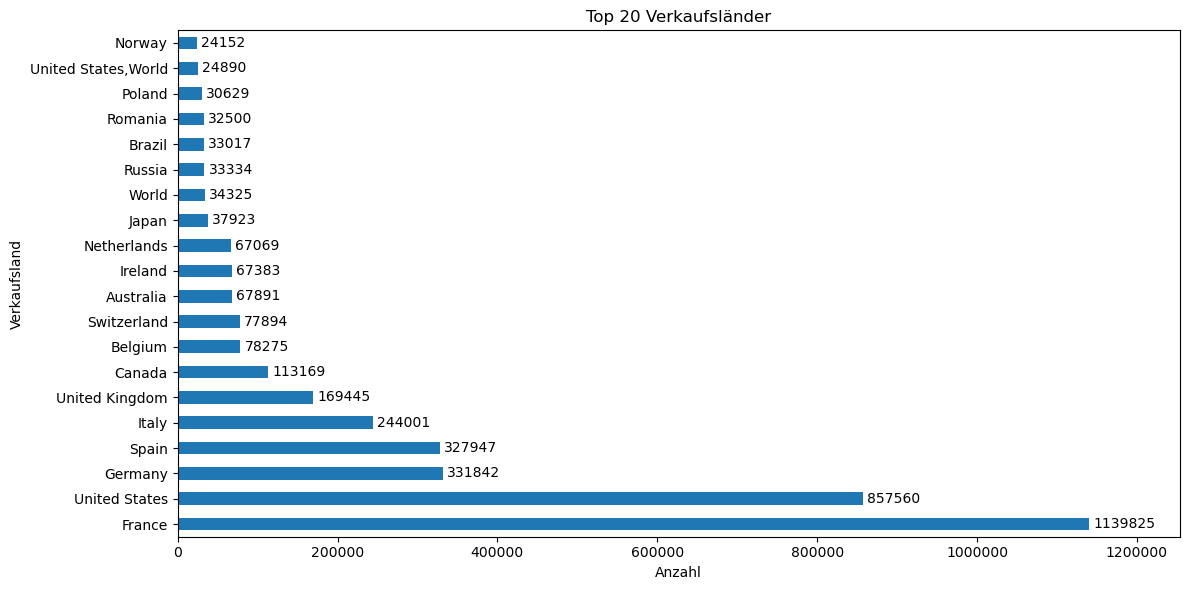

In [24]:
v7 = fdf["countries_en"].value_counts().head(20).plot(kind="barh", figsize=(12,6), title="Top 20 Verkaufsländer")
v7.set_xlabel("Anzahl")
v7.set_ylabel("Verkaufsland")
v7.ticklabel_format(style="plain", axis="x")
v7.bar_label(v7.containers[0], padding=3, fmt="%d")

plt.margins(x=0.1)
plt.tight_layout()
#plt.savefig('top20_verkaufsländer.png', dpi=300, bbox_inches='tight')
plt.show()

In [25]:
fdf["purchase_places"].value_counts().head(10)

purchase_places
France                    45561
Deutschland               12000
Portugal                   6102
España                     4563
Calgary,Alberta,Canada     4133
United Kingdom             3839
Lyon,France                3263
Italia                     3216
Courrières,France          2409
Paris,France               2262
Name: count, dtype: int64

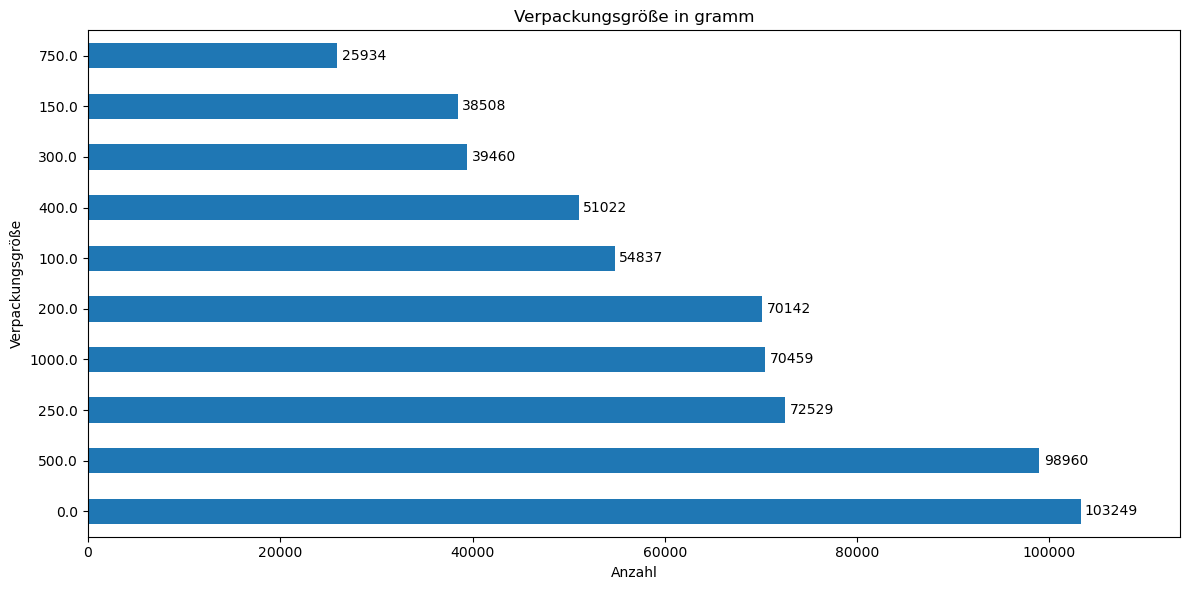

In [26]:
v8 = fdf["product_quantity"].value_counts().head(10).plot(kind="barh", figsize=(12,6), title="Verpackungsgröße in gramm")
v8.set_xlabel("Anzahl")
v8.set_ylabel("Verpackungsgröße")
v8.ticklabel_format(style="plain", axis="x")
v8.bar_label(v8.containers[0], padding=3, fmt="%d")

plt.margins(x=0.1)
plt.tight_layout()
plt.show()

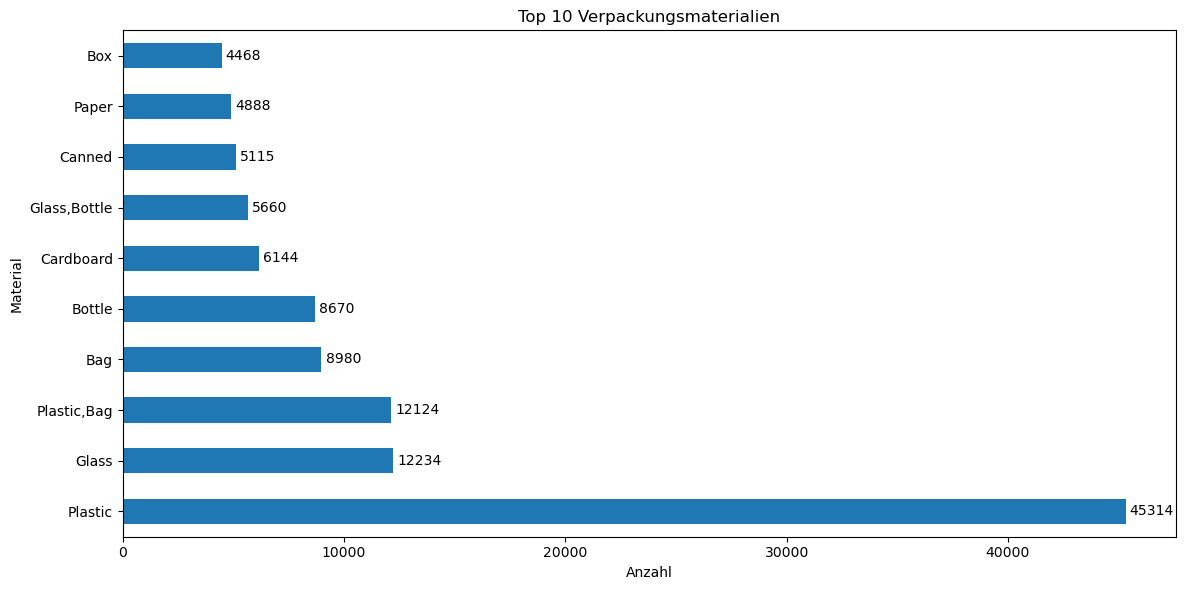

In [27]:
v9 = fdf["packaging_en"].value_counts().head(10).plot(kind="barh", figsize=(12,6), title="Top 10 Verpackungsmaterialien")
v9.set_xlabel("Anzahl")
v9.set_ylabel("Material")
v9.ticklabel_format(style="plain", axis="x")
v9.bar_label(v9.containers[0], padding=3, fmt="%d")

plt.tight_layout()
#plt.savefig('top10_verpackungsmaterialeien.png', dpi=300, bbox_inches='tight')
plt.show()

In [28]:
fdf["product_name"].value_counts().head(10)

product_name
Miel                            1984
Aceite de oliva virgen extra    1690
Spaghetti                       1616
Filet de poulet                 1550
Mozzarella                      1524
Chocolat                        1369
Comté                           1295
Poulet                          1210
Mayonnaise                      1168
Ketchup                         1137
Name: count, dtype: int64

In [29]:
fdf["brands"].value_counts().head(10)

brands
Carrefour    25657
Auchan       18070
Coop         13952
Lidl         13675
U            12273
BonÀrea      12193
Aldi         11554
Hacendado    10468
Tesco        10233
Delhaize      9675
Name: count, dtype: int64

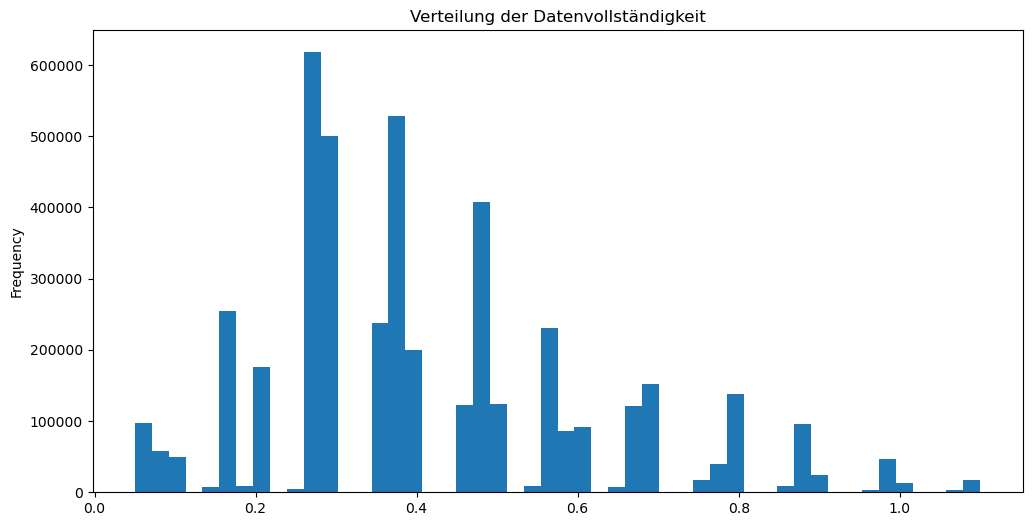

In [30]:
v10 = fdf["completeness"].plot(kind="hist", figsize=(12,6), bins=50, title="Verteilung der Datenvollständigkeit")


In [31]:
per_column = df.count()
per_column = per_column.sort_values(ascending=False)

per_column.head(40)

code                         4501355
created_t                    4501355
created_datetime             4501355
last_modified_t              4501355
last_modified_datetime       4501355
url                          4501355
states                       4501351
states_tags                  4501351
states_en                    4501351
creator                      4501349
completeness                 4501302
last_updated_t               4501160
last_updated_datetime        4501160
countries                    4478370
countries_en                 4478365
countries_tags               4478365
pnns_groups_1                4456623
pnns_groups_2                4456623
nutriscore_grade             4456509
last_modified_by             4362794
product_name                 4166210
environmental_score_grade    3635978
last_image_datetime          3454588
last_image_t                 3454588
image_url                    3332142
image_small_url              3332142
brands_tags                  2824003
b

In [32]:
ausreisser_namen_liste

['energy_100g',
 'energy-kcal_100g',
 'proteins_100g',
 'carbohydrates_100g',
 'fat_100g',
 'energy-kj_100g',
 'sugars_100g',
 'saturated-fat_100g',
 'salt_100g',
 'sodium_100g',
 'fiber_100g',
 'added-sugars_100g',
 'fruits-vegetables-legumes_100g']

In [33]:
temp = ["energy_100g", "energy-kcal_100g", "energy-kj_100g"]
pd.reset_option("display.width")
print(df[temp].dropna().sample(10))

         energy_100g  energy-kcal_100g  energy-kj_100g
2336902     1602.100           378.000        1602.100
3933726      419.500            99.000         419.500
120251      1603.200           379.000        1603.200
3516385      161.800            43.000         161.800
1521326     2570.500           645.000        2570.500
2393870     1208.000           291.000        1208.000
2786243     1609.019           604.775        1609.019
3467335      279.000            65.000         279.000
1346536     1387.000           320.000        1387.000
2413411      654.500           157.000         654.500


In [34]:
vergleich = df.dropna(subset=["energy_100g", "energy-kj_100g"])

vergleich["energy_100g"].equals(vergleich["energy-kj_100g"])

True

In [35]:
nutrient_col = ['energy-kcal_100g', 'proteins_100g', 'carbohydrates_100g', 'fat_100g',
                 'sugars_100g','saturated-fat_100g','salt_100g','sodium_100g']

df[nutrient_col].describe()

,energy-kcal_100g,proteins_100g,carbohydrates_100g,fat_100g,sugars_100g,saturated-fat_100g,salt_100g,sodium_100g
count,2201194.000,2181475.000,2178413.000,2177811.000,2114518.000,2099429.000,1922304.000,1922304.000
mean,6465898505.683,1704.729,33.345,22.260,555548552504372176365813760.000,5.483,116.370,46.566
std,9593078995948.131,1840637.389,9810.668,11904.178,807844390361581177423785885696.000,407.591,158330.703,63332.284
min,-113.860,-4.762,-0.115,-0.002,-0.087,-3.992,-0.454,-0.183
25%,109.000,2.000,3.000,1.170,0.600,0.200,0.098,0.039
50%,253.333,6.700,14.000,7.300,3.200,1.900,0.570,0.228
75%,394.000,14.000,50.000,21.000,14.400,7.000,1.400,0.560
max,14232696253056154.000,2522222222.000,14479774.250,17554003.530,1174717414144440050270536724381696.000,588000.000,219520780.944,87808312.377


In [36]:
daten = df[nutrient_col]

(daten < 0).sum()

energy-kcal_100g      1
proteins_100g         3
carbohydrates_100g    1
fat_100g              1
sugars_100g           1
saturated-fat_100g    3
salt_100g             4
sodium_100g           4
dtype: int64

In [37]:
temp = ['proteins_100g', 'carbohydrates_100g', 'fat_100g', 'sugars_100g','saturated-fat_100g', 'salt_100g', 'sodium_100g']
daten2 = df[temp]

(daten2 > 100).sum()

proteins_100g         300
carbohydrates_100g    833
fat_100g              428
sugars_100g           305
saturated-fat_100g    169
salt_100g             985
sodium_100g           610
dtype: int64

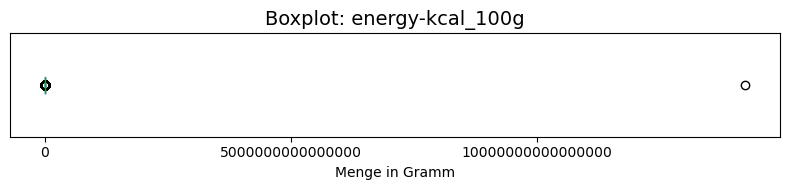

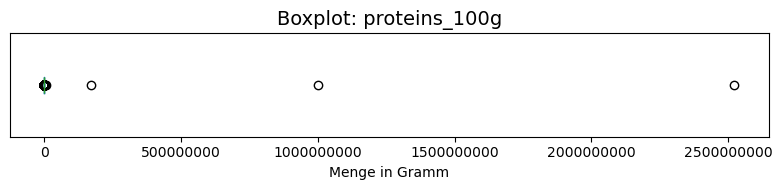

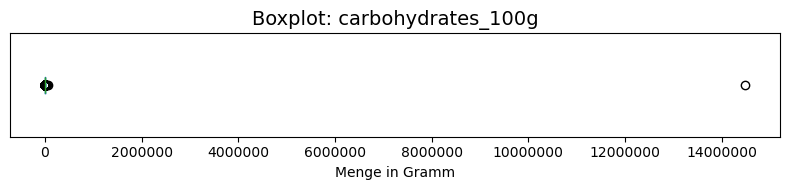

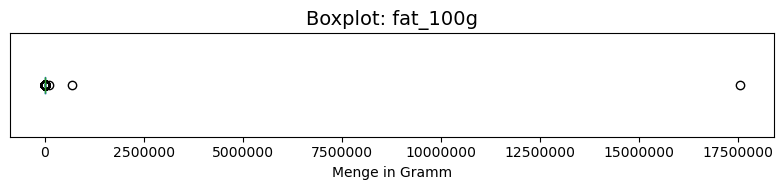

In [38]:
import matplotlib.pyplot as plt

makro = ["energy-kcal_100g", "proteins_100g", "carbohydrates_100g", "fat_100g"]

for col in makro:
    
    plt.figure(figsize=(8, 2))
    temp = df[col].plot(kind="box", vert=False)
    temp.ticklabel_format(style="plain", axis="x")
    if (col == "energy-kcal_100g"):
        temp.locator_params(axis="x", nbins="4")

    plt.title(f"Boxplot: {col}", fontsize=14)
    plt.xlabel("Menge in Gramm")

    plt.yticks([])

    plt.tight_layout()
    plt.show()
    

    

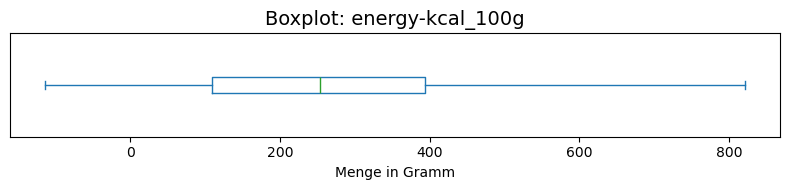

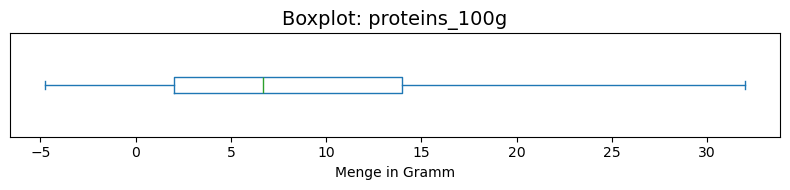

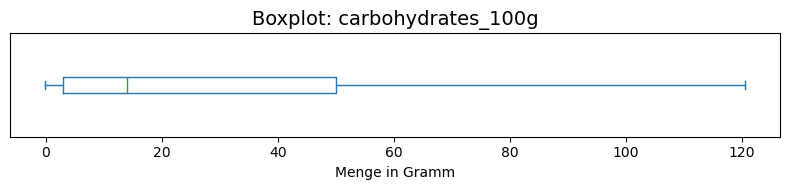

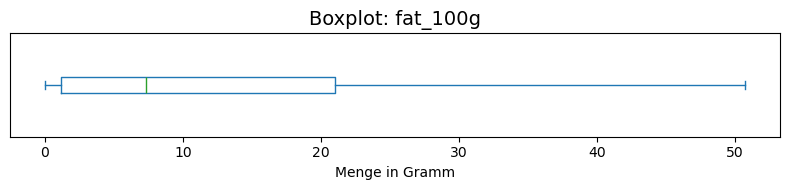

In [39]:
import matplotlib.pyplot as plt

makro = ["energy-kcal_100g", "proteins_100g", "carbohydrates_100g", "fat_100g"]

for col in makro:
    
    plt.figure(figsize=(8, 2))
    temp = df[col].plot(kind="box", showfliers=False, vert=False)
    temp.ticklabel_format(style="plain", axis="x")

    plt.title(f"Boxplot: {col}", fontsize=14)
    plt.xlabel("Menge in Gramm")

    plt.yticks([])

    plt.tight_layout()
    plt.show()
    

In [40]:
df["energy-kcal_100g"].value_counts().head(10)

energy-kcal_100g
0.000      33510
1.000      15677
400.000    12189
900.000     9490
350.000     9038
100.000     8818
500.000     8031
360.000     7379
46.000      7257
250.000     7210
Name: count, dtype: int64

In [41]:
df["proteins_100g"].value_counts().head(10)

proteins_100g
0.000     177291
0.500      57298
12.000     38003
11.000     32829
10.000     32402
20.000     31514
13.000     30554
14.000     26198
1.000      26030
21.000     24001
Name: count, dtype: int64

In [42]:
df["carbohydrates_100g"].value_counts().head(10)

carbohydrates_100g
0.000     157443
0.500      67016
1.000      44201
11.000     24557
12.000     23852
13.000     18406
10.000     17997
2.000      17970
14.000     17284
3.000      16101
Name: count, dtype: int64

In [43]:
df["fat_100g"].value_counts().head(10)

fat_100g
0.000     229986
0.500      85116
0.100      38969
1.000      28371
12.000     25949
0.200      25240
11.000     25113
10.000     24667
15.000     24552
20.000     24263
Name: count, dtype: int64

In [44]:
df["energy-kcal_100g"].nlargest(10)

1041470   14232696253056154.000
276200            115195467.000
404154             10000000.000
16541               3333333.000
3379664             2559236.000
3938161             1932459.000
2479974             1493354.000
3495048             1015384.615
4454043              623031.818
2595427              363000.000
Name: energy-kcal_100g, dtype: float64

In [45]:
df["proteins_100g"].nlargest(10)

3138119   2522222222.000
413768    1000000000.000
1291717    170587900.000
276200       4154001.760
979634        100000.000
4493758       100000.000
1417488        40939.000
388704          6400.000
2580036         6000.800
3404690         4600.000
Name: proteins_100g, dtype: float64

In [46]:
df["carbohydrates_100g"].nlargest(10)

276200    14479774.250
2635046      55935.500
404154       40000.000
3949894       8203.000
936959        7142.857
2874751       6519.000
3406989       6500.000
2375088       6475.700
302709        6400.000
3404666       6200.000
Name: carbohydrates_100g, dtype: float64

In [47]:
df["fat_100g"].nlargest(10)

276200    17554003.530
4485289     678454.000
2862009     111111.000
413768       10000.000
2783492       7605.000
721508        6806.000
2725719       5888.000
3224862       5856.650
56929         4444.000
35539         4367.143
Name: fat_100g, dtype: float64

In [18]:
import pandas as pd

# 1. Ausgewählte Spalten und Gesamtzeilen berechnen
auswahl = ['energy-kcal_100g', 'proteins_100g', 'carbohydrates_100g', 'fat_100g']
gesamt_zeilen = len(df)

# 2. Daten berechnen (Absolut und in Prozent)
absolute_zahlen = df[auswahl].count()
relative_zahlen = (absolute_zahlen / gesamt_zeilen) * 100

# 3. Eine saubere Tabelle (DataFrame) erstellen und absteigend sortieren
tabelle = pd.DataFrame({
    'Einträge (Absolut)': absolute_zahlen,
    'Vollständigkeit (%)': relative_zahlen
}).sort_values(by='Einträge (Absolut)', ascending=False)

# 4. Die Zahlen hübsch formatieren (Deutsche Schreibweise mit Punkten und Kommas)
tabelle['Einträge (Absolut)'] = tabelle['Einträge (Absolut)'].apply(lambda x: f"{x:,.0f}".replace(',', '.'))
tabelle['Vollständigkeit (%)'] = tabelle['Vollständigkeit (%)'].apply(lambda x: f"{x:.1f} %".replace('.', ','))

# 5. Tabelle im Notebook anzeigen
display(tabelle)

# Kopiert die fertig formatierte Tabelle direkt in deine Zwischenablage
tabelle.to_clipboard(excel=True, sep='\t')

,Einträge (Absolut),Vollständigkeit (%)
energy-kcal_100g,2.201.194,"48,9 %"
proteins_100g,2.181.475,"48,5 %"
carbohydrates_100g,2.178.413,"48,4 %"
fat_100g,2.177.811,"48,4 %"


In [49]:
import pandas as pd

# Deine Spalten für die Makronährstoffe
makros = ['proteins_100g', 'carbohydrates_100g', 'fat_100g']
namen_anzeige = ['Proteine', 'Kohlenhydrate', 'Fette']

# Leere Liste für die Ergebnisse
ergebnisse = []

for spalte, name in zip(makros, namen_anzeige):
    # Basis-Statistiken
    minimum = df[spalte].min()
    maximum = df[spalte].max()
    
    # Zählen der fehlerhaften Einträge
    unter_0 = (df[spalte] < 0).sum()
    ueber_100 = (df[spalte] > 100).sum()
    
    # Ergebnisse zur Liste hinzufügen
    ergebnisse.append({
        'Makronährstoff': name,
        'Minimum': round(minimum, 2),
        'Maximum': round(maximum, 2),
        'Fehlerhaft (< 0g)': unter_0,
        'Unmöglich (> 100g)': ueber_100
    })

# Tabelle (DataFrame) erstellen
tabelle_makros = pd.DataFrame(ergebnisse)

# Tabelle anzeigen
display(tabelle_makros)

,Makronährstoff,Minimum,Maximum,Fehlerhaft (< 0g),Unmöglich (> 100g)
0,Proteine,-4.760,2522222222.000,3,300
1,Kohlenhydrate,-0.110,14479774.250,1,833
2,Fette,-0.000,17554003.530,1,428


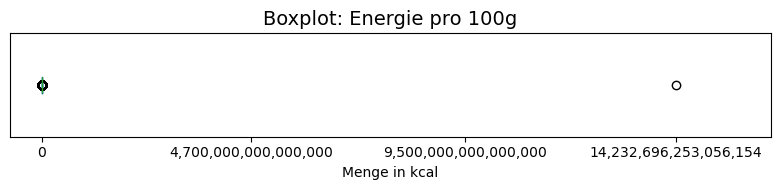

In [74]:
import matplotlib.pyplot as plt
import math

# --- 1. Hilfsfunktion für "schöne" runde Zahlen ---
def runde_schoen(wert):
    if wert <= 0:
        return 0
    # Berechnet, wie viele Stellen die Zahl hat
    stellen = int(math.log10(wert))
    # Rundet die Zahl z.B. bei Millionen auf die nächsten 100.000 ab/auf
    rundungs_faktor = -(stellen - 1) 
    return round(wert, rundungs_faktor)

plt.figure(figsize=(8, 2))

# 2. Boxplot erstellen
temp = df["energy-kcal_100g"].plot(kind="box", vert=False)

# 3. Maximalwert auslesen
max_wert = df["energy-kcal_100g"].max()

# 4. Zwischenwerte berechnen UND durch unsere neue Funktion schicken
drittel = runde_schoen(max_wert / 3)
zwei_drittel = runde_schoen((max_wert / 3) * 2)

# 5. X-Achse manuell definieren
tick_positionen = [0, drittel, zwei_drittel, max_wert]
tick_labels = [f"{wert:,.0f}" for wert in tick_positionen]

plt.xticks(ticks=tick_positionen, labels=tick_labels) 
plt.xlabel("Menge in kcal")

# 6. Y-Achse ausblenden
plt.yticks([]) 

# 7. Den rechten Rand leicht erweitern, damit der Text Platz hat
plt.xlim(right=max_wert * 1.15)

# 8. Titel setzen
plt.title("Boxplot: Energie pro 100g", fontsize=14)

plt.tight_layout()
plt.savefig("energie-kcal_boxplot", dpi=300)
plt.show()

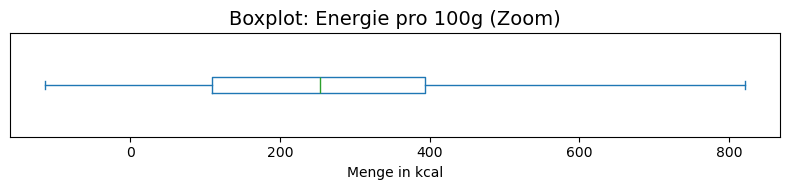

In [51]:
import matplotlib.pyplot as plt

    
plt.figure(figsize=(8, 2))
temp = df["energy-kcal_100g"].plot(kind="box", showfliers=False, vert=False)
temp.ticklabel_format(style="plain", axis="x")

plt.title("Boxplot: Energie pro 100g (Zoom)", fontsize=14)
plt.xlabel("Menge in kcal")

plt.yticks([])

plt.tight_layout()
#plt.savefig("energie-kcal_boxplot_zoom", dpi=300)
plt.show()

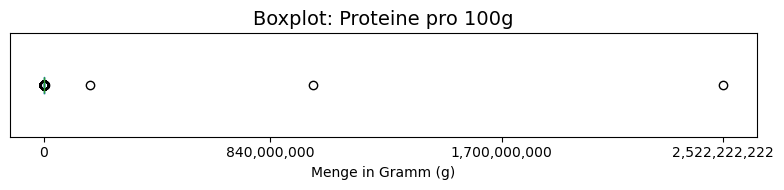

In [52]:
import matplotlib.pyplot as plt
import math

# --- 1. Hilfsfunktion für "schöne" runde Zahlen ---
def runde_schoen(wert):
    if wert <= 0:
        return 0
    # Berechnet, wie viele Stellen die Zahl hat
    stellen = int(math.log10(wert))
    # Rundet die Zahl z.B. bei Millionen auf die nächsten 100.000 ab/auf
    rundungs_faktor = -(stellen - 1) 
    return round(wert, rundungs_faktor)

plt.figure(figsize=(8, 2))

# 2. Boxplot erstellen
temp = df["proteins_100g"].plot(kind="box", vert=False)

# 3. Maximalwert auslesen
max_wert = df["proteins_100g"].max()

# 4. Zwischenwerte berechnen UND durch unsere neue Funktion schicken
drittel = runde_schoen(max_wert / 3)
zwei_drittel = runde_schoen((max_wert / 3) * 2)

# 5. X-Achse manuell definieren
tick_positionen = [0, drittel, zwei_drittel, max_wert]
tick_labels = [f"{wert:,.0f}" for wert in tick_positionen]

plt.xticks(ticks=tick_positionen, labels=tick_labels) 
plt.xlabel("Menge in Gramm (g)")

# 6. Y-Achse ausblenden
plt.yticks([]) 

# 7. Den rechten Rand leicht erweitern, damit der Text Platz hat
plt.xlim(right=max_wert * 1.05)

# 8. Titel setzen
plt.title("Boxplot: Proteine pro 100g", fontsize=14)

plt.tight_layout()
#plt.savefig("Proteine_boxplot", dpi=300)
plt.show()

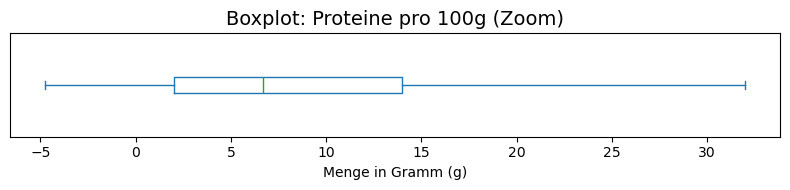

In [53]:
import matplotlib.pyplot as plt

    
plt.figure(figsize=(8, 2))
temp = df["proteins_100g"].plot(kind="box", showfliers=False, vert=False)
temp.ticklabel_format(style="plain", axis="x")

plt.title("Boxplot: Proteine pro 100g (Zoom)", fontsize=14)
plt.xlabel("Menge in Gramm (g)")

plt.yticks([])

plt.tight_layout()
#plt.savefig("Proteine_boxplot_zoom", dpi=300)
plt.show()

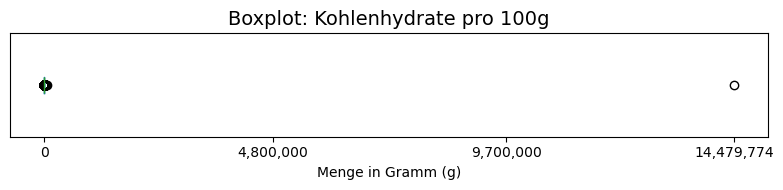

In [54]:
import matplotlib.pyplot as plt
import math

# --- 1. Hilfsfunktion für "schöne" runde Zahlen ---
def runde_schoen(wert):
    if wert <= 0:
        return 0
    # Berechnet, wie viele Stellen die Zahl hat
    stellen = int(math.log10(wert))
    # Rundet die Zahl z.B. bei Millionen auf die nächsten 100.000 ab/auf
    rundungs_faktor = -(stellen - 1) 
    return round(wert, rundungs_faktor)

plt.figure(figsize=(8, 2))

# 2. Boxplot erstellen
temp = df["carbohydrates_100g"].plot(kind="box", vert=False)

# 3. Maximalwert auslesen
max_wert = df["carbohydrates_100g"].max()

# 4. Zwischenwerte berechnen UND durch unsere neue Funktion schicken
drittel = runde_schoen(max_wert / 3)
zwei_drittel = runde_schoen((max_wert / 3) * 2)

# 5. X-Achse manuell definieren
tick_positionen = [0, drittel, zwei_drittel, max_wert]
tick_labels = [f"{wert:,.0f}" for wert in tick_positionen]

plt.xticks(ticks=tick_positionen, labels=tick_labels) 
plt.xlabel("Menge in Gramm (g)")

# 6. Y-Achse ausblenden
plt.yticks([]) 

# 7. Den rechten Rand leicht erweitern, damit der Text Platz hat
plt.xlim(right=max_wert * 1.05)

# 8. Titel setzen
plt.title("Boxplot: Kohlenhydrate pro 100g", fontsize=14)

plt.tight_layout()
#plt.savefig("Kohlenhydrate_boxplot", dpi=300)
plt.show()

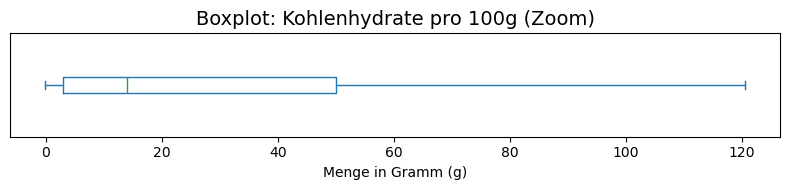

In [55]:
import matplotlib.pyplot as plt

    
plt.figure(figsize=(8, 2))
temp = df["carbohydrates_100g"].plot(kind="box", showfliers=False,  vert=False)
temp.ticklabel_format(style="plain", axis="x")

plt.title("Boxplot: Kohlenhydrate pro 100g (Zoom)", fontsize=14)
plt.xlabel("Menge in Gramm (g)")

plt.yticks([])

plt.tight_layout()
#plt.savefig("Kohlenhydrate_boxplot_zoom", dpi=300)
plt.show()

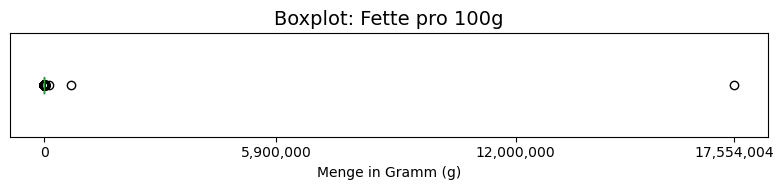

In [56]:
import matplotlib.pyplot as plt
import math

# --- 1. Hilfsfunktion für "schöne" runde Zahlen ---
def runde_schoen(wert):
    if wert <= 0:
        return 0
    # Berechnet, wie viele Stellen die Zahl hat
    stellen = int(math.log10(wert))
    # Rundet die Zahl z.B. bei Millionen auf die nächsten 100.000 ab/auf
    rundungs_faktor = -(stellen - 1) 
    return round(wert, rundungs_faktor)

plt.figure(figsize=(8, 2))

# 2. Boxplot erstellen
temp = df["fat_100g"].plot(kind="box", vert=False)

# 3. Maximalwert auslesen
max_wert = df["fat_100g"].max()

# 4. Zwischenwerte berechnen UND durch unsere neue Funktion schicken
drittel = runde_schoen(max_wert / 3)
zwei_drittel = runde_schoen((max_wert / 3) * 2)

# 5. X-Achse manuell definieren
tick_positionen = [0, drittel, zwei_drittel, max_wert]
tick_labels = [f"{wert:,.0f}" for wert in tick_positionen]

plt.xticks(ticks=tick_positionen, labels=tick_labels) 
plt.xlabel("Menge in Gramm (g)")

# 6. Y-Achse ausblenden
plt.yticks([]) 

# 7. Den rechten Rand leicht erweitern, damit der Text Platz hat
plt.xlim(right=max_wert * 1.05)

# 8. Titel setzen
plt.title("Boxplot: Fette pro 100g", fontsize=14)

plt.tight_layout()
#plt.savefig("Fette_boxplot", dpi=300)
plt.show()

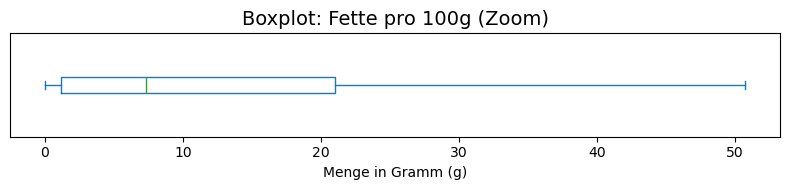

In [57]:
import matplotlib.pyplot as plt

    
plt.figure(figsize=(8, 2))
temp = df["fat_100g"].plot(kind="box", showfliers=False, vert=False)
temp.ticklabel_format(style="plain", axis="x")

plt.title("Boxplot: Fette pro 100g (Zoom)", fontsize=14)
plt.xlabel("Menge in Gramm (g)")

plt.yticks([])

plt.tight_layout()
#plt.savefig("Fette_boxplot_zoom", dpi=300)
plt.show()

In [58]:
import pandas as pd

df["created_datetime"] = pd.to_datetime(df["created_datetime"])

produkte_pro_jahr = df["created_datetime"].dt.year.value_counts().sort_index()

print(produkte_pro_jahr)

created_datetime
2012      4397
2013      9883
2014     13208
2015     34774
2016     45713
2017    283004
2018    323478
2019    366272
2020    466602
2021    512285
2022    595980
2023    356801
2024    547686
2025    673789
2026    267483
Name: count, dtype: int64


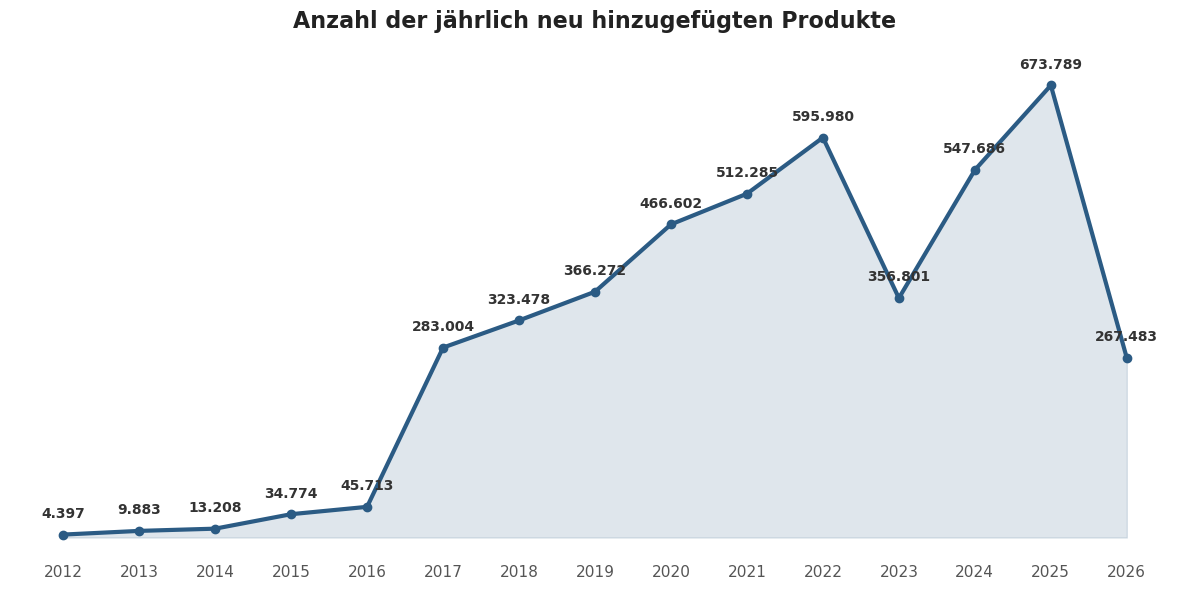

In [59]:
import matplotlib.pyplot as plt
import pandas as pd

# 1. Datumsspalte vorbereiten (falls noch nicht geschehen)
df['created_datetime'] = pd.to_datetime(df['created_datetime'], errors='coerce')

# 2. Jahre extrahieren und zählen (ohne das originale df zu verändern!)
# .sort_index() stellt sicher, dass die Jahre chronologisch von links nach rechts verlaufen
zeitreihe = df['created_datetime'].dt.year.value_counts().sort_index()

# 3. Diagramm im eleganten 16:9 Format für Präsentationen erstellen
fig, ax = plt.subplots(figsize=(12, 6))

# 4. Den Trend zeichnen: Eine dicke Linie mit einer sanften Farbfläche darunter
ax.plot(zeitreihe.index, zeitreihe.values, color='#2B5B84', linewidth=3, 
        marker='o', markersize=6, label='Neu erstellte Produkte')
ax.fill_between(zeitreihe.index, zeitreihe.values, color='#2B5B84', alpha=0.15)

# 5. Design-Trick: Die genauen Zahlen direkt über die Punkte schreiben
for jahr, anzahl in zeitreihe.items():
    # Formatiert die Zahl mit deutschen Tausendertrennzeichen (z.B. 150.000)
    text = f"{anzahl:,}".replace(',', '.')
    
    ax.annotate(text, 
                xy=(jahr, anzahl), 
                xytext=(0, 12),          # 12 Punkte Abstand nach oben über den Punkt
                textcoords='offset points', 
                ha='center',             # Horizontal zentriert über dem Punkt
                fontsize=10, 
                fontweight='bold',
                color='#333333')

# 6. Unnötigen "Chart-Ballast" entfernen (Minimalismus-Prinzip)
ax.set_xticks(zeitreihe.index)  # Jedes Jahr auf der X-Achse markieren
ax.tick_params(axis='x', labelsize=11, colors='#555555', length=0) # Keine Achsenstriche

# Alle Rahmenlinien und die Y-Achse löschen, da die Werte direkt an den Punkten stehen
for spine in ['top', 'right', 'left', 'bottom']:
    ax.spines[spine].set_visible(False)
ax.get_yaxis().set_visible(False)

# 7. Professioneller, linksbündiger Titel
plt.title('Anzahl der jährlich neu hinzugefügten Produkte', 
          fontsize=16, fontweight='bold', pad=25, color='#222222', loc='center')

plt.tight_layout()

# Tipp zum Speichern für PowerPoint (ohne Hintergrund, hochauflösend):
#plt.savefig('zeitliche_entwicklung.png', dpi=300)

plt.show()

In [8]:
# 1. Wir definieren die drei Bedingungen
# (Falls deine Spalte für Kohlenhydrate anders heißt, z.B. 'carbohydrates_100g', tausche es einfach aus)
bed_protein = (df['proteins_100g'] == 0.0)
bed_fett = (df['fat_100g'] == 0.0)
bed_kohlenhydrate = (df['carbohydrates_100g'] == 0.0)
bed_energie = (df["energy-kcal_100g"] == 0.0)

# 2. Wir filtern das DataFrame, indem wir verlangen, dass ALLE drei Bedingungen gelten (&)
produkte_null_makros = df[bed_fett]

# 3. Wir zählen wieder die Kategorien aus
top_kategorien = produkte_null_makros['main_category_en'].value_counts().head(20)

print(top_kategorien)

main_category_en
Sweetened beverages            6053
Beverages                      4645
Groceries                      4001
Candies                        2758
Honeys                         1675
Sodas                          1670
Teas                           1660
Yogurts                        1653
Energy drinks                  1409
Herbal teas                    1147
Fruit juices                   1068
Dietary supplements            1045
Kombuchas                      1043
Iced teas                       975
Natural mineral waters          818
Greek-style yogurts             720
Strawberry jams                 705
Sugar-free chewing gum          679
Balsamic vinegars of Modena     674
Coffees                         671
Name: count, dtype: int64
